# Gradient Boosting (XGBoost) — a step-by-step, runnable notebook

Gradient boosting builds shallow trees **sequentially**: each new tree fits the **residual error** the current ensemble still makes, and is added on with a small learning rate. Do that carefully and you get **XGBoost / LightGBM / CatBoost** — the reigning champions of tabular data. The deep idea, which we will *measure*, is that 'fit the residuals' is exactly **gradient descent in function space**: each tree approximates the negative gradient of the loss with respect to the current predictions.

This notebook builds that, one measurement at a time, on **real scikit-learn datasets** (no manual download): **California Housing** (20,640 districts, seeded-subsampled for a fast from-scratch loop) for the regression story, and **Breast Cancer** (569 tumours) for the log-loss classification loop. It is the executable companion to the chapter and to `gradient_boosting.py`; every function used here lives in that module, imported so the notebook and the module can never drift apart. Real **XGBoost** is used where the chapter cites it.

By the end you will have **measured**, not just been told:

1. that the **pseudo-residual is the negative gradient** — `y - F` for squared error, `y - p` for log-loss;
2. a gradient-boosting ensemble **grown from scratch** whose loss falls every round and **matches** scikit-learn;
3. the **staged train/validation curve** — train falls forever while validation dips then RISES (early stopping);
4. the **learning-rate ↔ n_estimators trade** — a small rate needs more trees but generalizes better;
5. the **residual-shrinking movie** — the ensemble staircase converging to the trend on one real feature;
6. XGBoost's **regularized leaf weight** `w* = -G/(H+λ)` and **split gain**, on real numbers;
7. why **gradient-boosted trees win tabular data**, measured against a tree and a forest.

Everything runs on CPU in a few seconds, seeded for reproducibility.

## Step 0 — Setup and version banner

We import the real functions from the chapter module (so this notebook uses the *exact same code* the figures and the page use) and print the library versions the results were produced on.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import xgboost

from gradient_boosting import (
    verify_gradient_identity, GradientBoostingScratch, verify_against_sklearn,
    load_california, load_cancer, staged_curve, learning_rate_sweep,
    residual_movie, xgboost_leaf_gain, boost_classification, model_comparison,
)

print(f'numpy {np.__version__} | scikit-learn {sklearn.__version__} | xgboost {xgboost.__version__}')
cal = load_california()
print(f'California Housing: {cal.x_train.shape[0]} train + {cal.x_test.shape[0]} test districts, '
      f'{cal.x_train.shape[1]} features {cal.feature_names}')

numpy 2.4.6 | scikit-learn 1.9.0 | xgboost 3.3.0
California Housing: 2250 train + 750 test districts, 8 features ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Step 1 — The pseudo-residual IS the negative gradient

Boosting fits each tree to the **negative gradient of the loss** with respect to the current prediction $F(x_i)$ — the *pseudo-residual*. The name 'gradient' comes from here. Two cases that matter, derived:

- **squared error** $L=\tfrac12(y-F)^2$: $\;\partial L/\partial F = -(y-F)$, so $-\text{grad}=y-F$ — the **ordinary residual**;
- **log-loss** with $p=\sigma(F)$: $\;\partial L/\partial F = p-y$, so $-\text{grad}=y-p$.

'Fit the residuals' *is* 'fit the negative gradient'. Let's confirm both to machine zero.

In [2]:
ident = verify_gradient_identity()
print(f'MSE      : -grad = {ident.mse_neg_grad:+.4f}   y-F = {ident.mse_residual:+.4f}   '
      f'match={ident.mse_match}')
print(f'log-loss : -grad = {ident.logloss_neg_grad:+.4f}   y-p = {ident.logloss_residual:+.4f}   '
      f'match={ident.logloss_match}')
print('\nThe residual and the negative gradient are literally the same number — that is why it is')
print('called GRADIENT boosting.')

MSE      : -grad = +1.0000   y-F = +1.0000   match=True
log-loss : -grad = +0.4013   y-p = +0.4013   match=True

The residual and the negative gradient are literally the same number — that is why it is
called GRADIENT boosting.


## Step 2 — Boost from scratch: the loss falls every round

The whole algorithm: start at the constant $F_0=\bar y$ (the mean, which minimizes squared error), then each round compute the residual $r=y-F$, fit a shallow tree to it, and add a shrunken step $F\leftarrow F+\eta\,h$. `GradientBoostingScratch` does exactly this. Watch the training MSE fall as the ensemble chips away at the leftover error.

In [3]:
gb = GradientBoostingScratch(n_estimators=60, learning_rate=0.3, max_depth=3).fit(cal.x_train, cal.y_train)
staged = gb.staged_predict(cal.x_train)   # predictions after 0, 1, 2, ... rounds
for m in (1, 5, 10, 30, 60):
    mse = np.mean((cal.y_train - staged[m]) ** 2)
    print(f'after {m:>2} rounds: train MSE = {mse:.4f}')
print('\nEach shallow tree fits the residual the ensemble still gets wrong — bias reduction in action.')

after  1 rounds: train MSE = 0.9514
after  5 rounds: train MSE = 0.4849
after 10 rounds: train MSE = 0.3437
after 30 rounds: train MSE = 0.2193
after 60 rounds: train MSE = 0.1498

Each shallow tree fits the residual the ensemble still gets wrong — bias reduction in action.


## Step 3 — Is it the real thing? Verify against scikit-learn

Grown with the **same** `learning_rate`, `max_depth`, and `n_estimators`, our from-scratch ensemble should trace the **same validation-loss curve** as scikit-learn's `GradientBoostingRegressor`, round for round. (We compare loss *curves* rather than demanding identical per-point predictions: when two candidate splits tie on gain, each implementation breaks the tie with its own RNG, so a different-but-equally-good tree is legitimate — same subtlety as a single decision tree.)

In [4]:
match = verify_against_sklearn(cal)
print(f'from-scratch test MSE : {match.scratch_test_mse:.5f}')
print(f'scikit-learn test MSE : {match.sklearn_test_mse:.5f}')
print(f'worst per-round validation-loss gap over {match.n_estimators} rounds: {match.max_staged_loss_gap:.5f}')
print('\n=> same loss curve round for round: the from-scratch loop IS scikit-learn\'s GBM.')

from-scratch test MSE : 0.28744
scikit-learn test MSE : 0.28876
worst per-round validation-loss gap over 60 rounds: 0.00133

=> same loss curve round for round: the from-scratch loop IS scikit-learn's GBM.


## Step 4 — Why boosting overfits: the staged train/validation curve

Unlike a random forest, **more trees CAN overfit** a boosted model — each tree keeps reducing *training* error, so eventually the ensemble fits the noise. Run a long boosting run and watch training MSE fall forever while **validation** MSE dips to a minimum and then turns back **up**. That minimum is exactly the round an early-stopping rule would keep.

In [5]:
curve = staged_curve(cal)
for r in (1, 10, 50, curve.best_round, 300, 500):
    i = r - 1
    mark = '   <- best val (early stop)' if r == curve.best_round else ''
    print(f'round {r:>4}: train MSE = {curve.train_mse[i]:.4f}   val MSE = {curve.val_mse[i]:.4f}{mark}')
print(f'\nbest validation MSE {curve.best_val_mse:.4f} at round {curve.best_round}; '
      f'train keeps falling to {curve.train_mse[-1]:.4f}.')

round    1: train MSE = 1.1661   val MSE = 1.1403
round   10: train MSE = 0.5343   val MSE = 0.5633
round   50: train MSE = 0.1901   val MSE = 0.2976
round  179: train MSE = 0.0900   val MSE = 0.2712   <- best val (early stop)
round  300: train MSE = 0.0536   val MSE = 0.2763
round  500: train MSE = 0.0268   val MSE = 0.2742

best validation MSE 0.2712 at round 179; train keeps falling to 0.0268.


## Step 5 — The overfitting U-turn, plotted

The growing **gap** between train and validation is overfitting made visible. The dashed line marks the validation minimum — the number of trees you should actually keep.

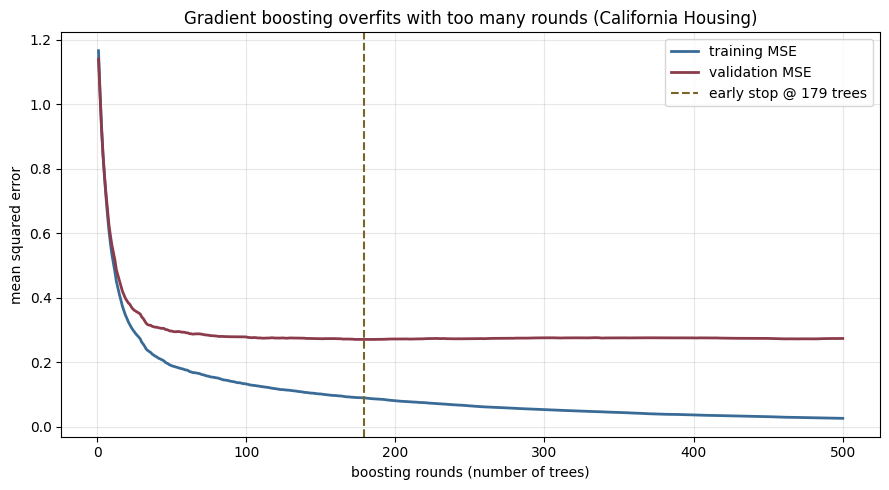

In [6]:
r = curve.rounds
plt.figure(figsize=(9, 5))
plt.plot(r, curve.train_mse, color='#3A6B96', lw=2.0, label='training MSE')
plt.plot(r, curve.val_mse, color='#8B3B4A', lw=2.0, label='validation MSE')
plt.axvline(curve.best_round, color='#7A6528', ls='--', lw=1.5,
            label=f'early stop @ {curve.best_round} trees')
plt.xlabel('boosting rounds (number of trees)')
plt.ylabel('mean squared error')
plt.title('Gradient boosting overfits with too many rounds (California Housing)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6 — The learning-rate ↔ n_estimators trade

`learning_rate` and `n_estimators` trade off. A big rate descends fast but overshoots and overfits within a few trees; a small rate takes many more trees but reaches a **lower** minimum — shrinkage acts as regularization. Measure the validation minimum and the rounds it takes for four rates.

In [7]:
sweep = learning_rate_sweep(cal)
print(f'{"learning_rate":>14}{"best val MSE":>14}{"rounds to best":>16}')
for lr, best_mse, best_round in zip(sweep.learning_rates, sweep.best_val_mses, sweep.best_rounds):
    print(f'{lr:>14}{best_mse:>14.4f}{best_round:>16}')
print('\nSmaller rate -> many more trees -> lower/flatter minimum. The standard recipe: small lr,')
print('many trees, and early stopping.')

 learning_rate  best val MSE  rounds to best
           1.0        0.4027               7
           0.3        0.3096              23
           0.1        0.2712             179
          0.03        0.2707             685

Smaller rate -> many more trees -> lower/flatter minimum. The standard recipe: small lr,
many trees, and early stopping.


## Step 7 — The shrinkage trade, plotted

Each curve is one learning rate's validation MSE vs number of trees; the dot is its minimum. See the big rate bottom out early and high, the small rates descend slowly to a lower floor.

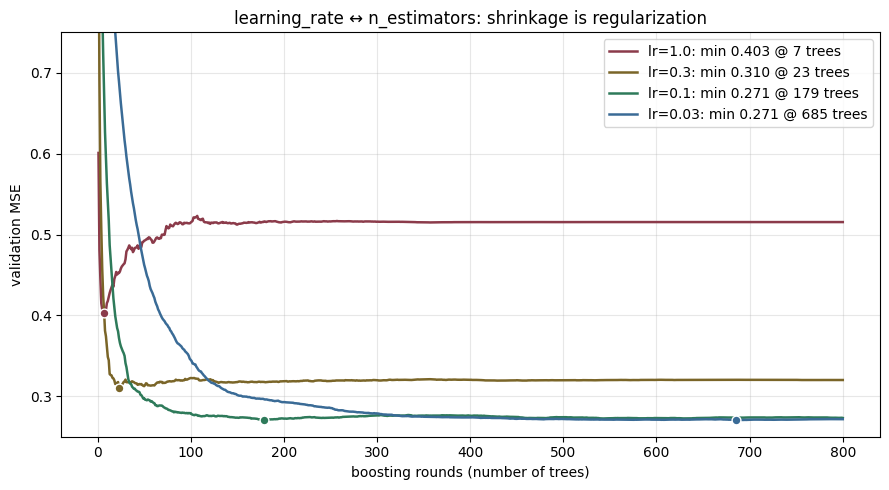

In [8]:
colours = ['#8B3B4A', '#7A6528', '#2E7A5A', '#3A6B96']
plt.figure(figsize=(9, 5))
for lr, vcurve, br, bm, c in zip(sweep.learning_rates, sweep.val_curves, sweep.best_rounds,
                                 sweep.best_val_mses, colours):
    rr = np.arange(1, len(vcurve) + 1)
    plt.plot(rr, vcurve, color=c, lw=1.8, label=f'lr={lr}: min {bm:.3f} @ {br} trees')
    plt.scatter([br], [bm], color=c, s=40, zorder=5, edgecolor='white')
plt.ylim(0.25, 0.75)
plt.xlabel('boosting rounds (number of trees)')
plt.ylabel('validation MSE')
plt.title('learning_rate ↔ n_estimators: shrinkage is regularization')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8 — The residual-shrinking movie (one real feature)

Boost on a **single real feature** (`MedInc`, median income) so the ensemble prediction is a 1-D staircase you can literally watch refine. After 1 round it is a coarse step; after 100 it hugs the income→value trend. The residual RMS falls at every checkpoint.

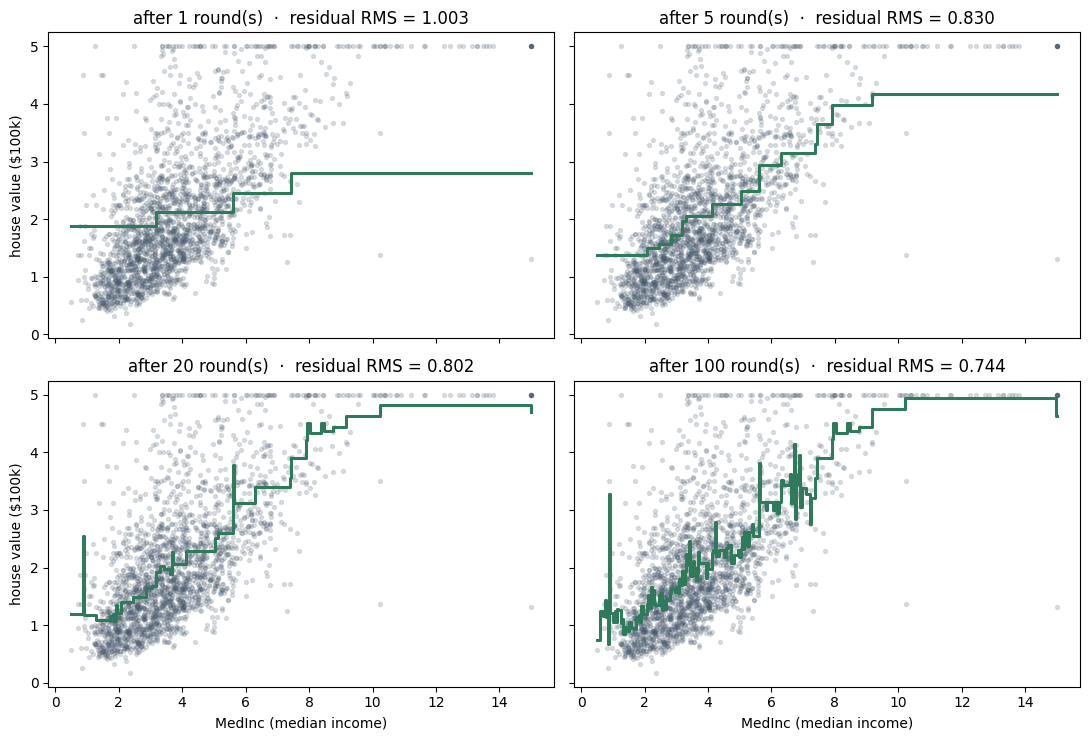

residual RMS: ['1.003', '0.830', '0.802', '0.744'] <- falls every checkpoint


In [9]:
movie = residual_movie(cal)
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True, sharey=True)
for ax, rounds, pred, rms in zip(axes.ravel(), movie.checkpoints, movie.predictions, movie.residual_rms):
    ax.scatter(movie.x, movie.y, s=8, color='#4A5B6E', alpha=0.18)
    ax.plot(movie.grid, pred, color='#2E7A5A', lw=2.2, drawstyle='steps-mid')
    ax.set_title(f'after {rounds} round(s)  ·  residual RMS = {rms:.3f}')
for ax in axes[-1]:
    ax.set_xlabel('MedInc (median income)')
for ax in axes[:, 0]:
    ax.set_ylabel('house value ($100k)')
plt.tight_layout()
plt.show()
print('residual RMS:', [f'{r:.3f}' for r in movie.residual_rms], '<- falls every checkpoint')

## Step 9 — XGBoost's regularized leaf weight and split gain

XGBoost sharpens plain boosting with a **second-order** objective (gradient *and* Hessian) plus explicit regularization. Minimizing it gives the closed-form optimal leaf weight $w^*=-G/(H+\lambda)$ and the split gain $\tfrac12[G_L^2/(H_L+\lambda)+G_R^2/(H_R+\lambda)-G^2/(H+\lambda)]-\gamma$. Compute them on the chapter's five-sample worked example (squared error, so each Hessian $h_i=1$).

In [10]:
split = xgboost_leaf_gain()   # g=(-0.8,-0.6,0.5,0.7,0.9), left={1,2}, right={3,4,5}, lambda=1, gamma=0
print(f'optimal leaf weights: w_left={split.w_left:+.2f}  w_right={split.w_right:+.2f}  '
      f'w_parent={split.w_parent:+.2f}')
print(f'split gain = {split.gain:.3f}  ->  {"KEEP the split" if split.kept else "PRUNE the split"}')
print('\nThe under-predicted samples (g<0) go left with a positive weight; the over-predicted (g>0) go')
print('right with a negative weight. gain>0, so the regularized loss drops and XGBoost keeps the split.')

optimal leaf weights: w_left=+0.47  w_right=-0.53  w_parent=-0.12
split gain = 0.837  ->  KEEP the split

The under-predicted samples (g<0) go left with a positive weight; the over-predicted (g>0) go
right with a negative weight. gain>0, so the regularized loss drops and XGBoost keeps the split.


## Step 10 — Boosting for classification (log-loss), from scratch

The same machine does classification: accumulate **log-odds** across trees, and read the output through a sigmoid. Init at the base-rate log-odds; each round the pseudo-residual is $y-p$, and each leaf's value is the **Newton step** $\sum(y-p)/\sum p(1-p)$. We store each round's Newton leaf values and score on a **held-out test split**, so both log-losses are clearly above zero — a real equality check, not two memorized-to-zero numbers. The from-scratch log-loss should match `GradientBoostingClassifier` on the unseen Breast Cancer tumours.

In [11]:
cancer = load_cancer()
cls = boost_classification(cancer)
print(f'from-scratch test log-loss : {cls.scratch_test_log_loss:.5f}')
print(f'scikit-learn test log-loss : {cls.sklearn_test_log_loss:.5f}')
gap = abs(cls.scratch_test_log_loss - cls.sklearn_test_log_loss)
print(f'gap = {gap:.5f}   (both non-trivial, matched on held-out data)')
assert gap < 0.05
print('\ny-p residuals + Newton leaf values reproduce scikit-learn\'s classifier on UNSEEN data.')

from-scratch test log-loss : 0.18766
scikit-learn test log-loss : 0.17728
gap = 0.01038   (both non-trivial, matched on held-out data)

y-p residuals + Newton leaf values reproduce scikit-learn's classifier on UNSEEN data.


## Step 11 — Why gradient-boosted trees win tabular data

The honest, measured comparison on one California test split: a single tree (high variance), a random forest (bagging → variance down), scikit-learn gradient boosting and real **XGBoost** (boosting → bias down, regularized). Boosting edges out the forest, which crushes the single tree.

In [12]:
comp = model_comparison(cal)
print(f'{"model":<26}{"test R^2":>10}{"test RMSE":>12}')
for name, r2, rmse in zip(comp.names, comp.r2, comp.rmse):
    print(f'{name.replace(chr(10), " "):<26}{r2:>10.3f}{rmse:>12.4f}')
print('\nsingle tree < random forest < gradient boosting <= XGBoost: bias-reduced ensembles win tabular.')

model                       test R^2   test RMSE
single tree (depth 8)          0.607      0.7078
random forest (300 x depth 12)     0.754      0.5601
sklearn GBM (300 x depth 3)     0.788      0.5196
XGBoost (300 x depth 3)        0.797      0.5094

single tree < random forest < gradient boosting <= XGBoost: bias-reduced ensembles win tabular.


## Step 12 — Real XGBoost with early stopping (the production workflow)

Finally, the real-world recipe with the actual library: set `n_estimators` to a large **upper bound**, use a **small** `learning_rate`, pass an `eval_set`, and let `early_stopping_rounds` pick the tree count for you. The model stops when validation stops improving and keeps the best iteration — never the last.

In [13]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

model = XGBRegressor(
    n_estimators=2000,          # an UPPER BOUND — early stopping picks the real count
    learning_rate=0.05,         # small lr + many trees + early stopping = the recipe
    max_depth=4, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    early_stopping_rounds=50, eval_metric='rmse', random_state=0, n_jobs=-1)
model.fit(cal.x_train, cal.y_train, eval_set=[(cal.x_test, cal.y_test)], verbose=False)

print(f'best_iteration (early-stopped) = {model.best_iteration}   (<< 2000)')
print(f'test R^2 at best_iteration      = {r2_score(cal.y_test, model.predict(cal.x_test)):.3f}')
imp = model.get_booster().get_score(importance_type='gain')
top = sorted(imp.items(), key=lambda kv: -kv[1])[:3]
print('top-3 features by gain:', [f'{cal.feature_names[int(k[1:])]}={v:.0f}' for k, v in top])

best_iteration (early-stopped) = 440   (<< 2000)
test R^2 at best_iteration      = 0.799
top-3 features by gain: ['MedInc=10', 'AveOccup=3', 'Longitude=3']


## Recap

On real scikit-learn datasets (plus real XGBoost), one runnable notebook built the whole of gradient boosting:

| Step | What we measured | The takeaway |
|---|---|---|
| 1 | pseudo-residual = negative gradient | `y - F` (MSE) and `y - p` (log-loss), to machine zero |
| 2–3 | boost from scratch; verify vs sklearn | loss falls every round; **same loss curve** as scikit-learn |
| 4–5 | the staged curve | train ↓ forever, validation dips then **RISES** — early-stop at the minimum |
| 6–7 | learning-rate ↔ n_estimators | small rate, more trees, lower minimum — shrinkage as regularization |
| 8 | the residual movie | the ensemble staircase **converges** to the trend; residual RMS falls |
| 9 | XGBoost leaf weight & gain | $w^*=-G/(H+\lambda)$; gain>0 keeps the split, gain<0 prunes it |
| 10 | log-loss boosting from scratch | `y-p` residuals + Newton leaf values reproduce scikit-learn |
| 11–12 | model comparison; real XGBoost | boosting > forest > tree; early stopping picks the tree count |

**Gradient boosting adds shallow trees sequentially, each fitting the negative gradient of the loss, with a small learning rate — gradient descent in function space.** It reduces **bias** (vs a forest's variance), it **can overfit** with too many trees (use early stopping), and its modern implementations — XGBoost, LightGBM, CatBoost — dominate tabular machine learning.